# Benchmark: keyless versioning on famous datasets

We pit four ways of versioning a **keyless** table against each other on well-known public datasets that genuinely lack a primary key.

| system | identity | what an edit costs |
|---|---|---|
| **naive** | none -- store every version in full | a full snapshot |
| **hash-only** | content hash (exact) | delete + full re-insert |
| **DeltaTrace** | exact hash **+ fuzzy** | the changed cells |
| **oracle** | a hidden ground-truth key | the changed cells (best case) |

**Methodology.** A public dataset is a single snapshot, so we synthesise a realistic *history*: each version edits ~6% of rows, inserts ~2%, deletes ~2%. Every row secretly carries a true key so we can (a) run an oracle and (b) score how well each system *recovers* identity. The keyless systems never see that key.

Two questions:

1. **Identity recovery** -- can the system tell an edit from a delete+insert?
2. **Storage** -- how big is the versioned store?

...and one invariant that must always hold: **every version reconstructs exactly.**

In [1]:
import sys, pathlib
# make the repo root importable whether this runs from notebooks/ or the root
_root = pathlib.Path.cwd()
while not (_root / "benchmarks").exists() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root))

import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})


## The datasets (all keyless)

In [2]:
from benchmarks.datasets import DATASETS, load
rows = []
for name, spec in DATASETS.items():
    df = load(name)
    rows.append({"dataset": name, "rows": len(df), "cols": df.shape[1],
                 "block_on": ", ".join(spec.block_on), "why keyless": spec.why_keyless})
pd.set_option("display.max_colwidth", 90)
pd.DataFrame(rows)

,dataset,rows,cols,block_on,why keyless
0,iris,150,5,species,150 flower measurements; a row is just four numbers + a species label. Two flowers can...
1,penguins,344,7,"species, island",344 penguin observations with missing values and no tag/ID; identity is purely the (of...
2,titanic,891,14,"pclass, sex","891 passengers with no manifest ID; many share class, sex, age and fare, and ages are ..."
3,diamonds,20000,10,"cut, color, clarity",~54k diamonds described only by physical attributes; thousands of rows are exact dupli...
4,adult,20000,14,"workclass, education, sex",~32k US census respondents described only by demographics; there is no respondent ID a...


## Run the benchmark

Build a 10-version history for each dataset and measure every system. (First run downloads + caches the datasets; a couple of minutes total.)

In [3]:
from benchmarks.run import run_all, storage_table, identity_table
runs = run_all(n_versions=10, seed=0)
storage = storage_table(runs)
identity = identity_table(runs)
assert storage["reconstruct_ok"].all(), "a system failed to reconstruct exactly!"
print("All systems reconstruct every version of every dataset exactly.\n")
storage

All systems reconstruct every version of every dataset exactly.



,dataset,system,bytes,kb,vs_naive,saved_pct,reconstruct_ok
0,iris,naive,46312,45.2,1.000,0.0,True
1,iris,hash-only,58965,57.6,1.273,-27.3,True
2,iris,deltatrace,88599,86.5,1.913,-91.3,True
3,iris,oracle,78915,77.1,1.704,-70.4,True
4,penguins,naive,76360,74.6,1.000,0.0,True
5,penguins,hash-only,81394,79.5,1.066,-6.6,True
6,penguins,deltatrace,112687,110.0,1.476,-47.6,True
7,penguins,oracle,98790,96.5,1.294,-29.4,True
8,titanic,naive,134796,131.6,1.000,0.0,True
9,titanic,hash-only,137707,134.5,1.022,-2.2,True


## 1. Identity recovery (the universal win)

How well does each matcher link an edited row back to its original? Hash-only has perfect precision but its **recall collapses** -- it cannot recognise *any* edited row, because a changed row no longer hashes to anything in the parent. DeltaTrace recovers ~99%.

In [4]:
identity

,dataset,system,precision,recall,f1,tp,fp,fn
0,iris,hash-only,1.000,0.944,0.971,909,0,54
1,iris,deltatrace,0.986,0.996,0.991,959,14,4
2,penguins,hash-only,1.000,0.941,0.969,2056,0,130
3,penguins,deltatrace,0.984,0.994,0.989,2172,35,14
4,titanic,hash-only,0.999,0.948,0.973,5378,5,295
5,titanic,deltatrace,0.974,0.989,0.982,5611,148,62
6,diamonds,hash-only,1.000,0.940,0.969,119899,1,7640
7,diamonds,deltatrace,0.985,0.996,0.990,127020,1959,519
8,adult,hash-only,0.998,0.944,0.970,120363,221,7176
9,adult,deltatrace,0.976,0.993,0.985,126667,3067,872


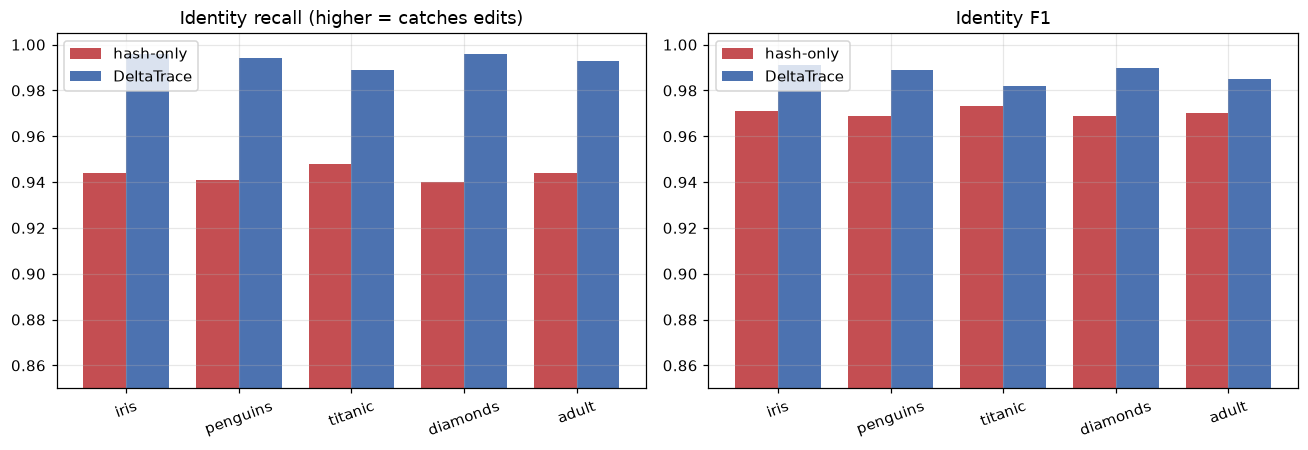

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
ds = list(DATASETS.keys())
x = np.arange(len(ds)); w = 0.38
for ax, metric, title in [(axes[0], "recall", "Identity recall (higher = catches edits)"),
                          (axes[1], "f1", "Identity F1")]:
    ho = [identity[(identity.dataset == d) & (identity.system == "hash-only")][metric].iloc[0] for d in ds]
    dt = [identity[(identity.dataset == d) & (identity.system == "deltatrace")][metric].iloc[0] for d in ds]
    ax.bar(x - w/2, ho, w, label="hash-only", color="#C44E52")
    ax.bar(x + w/2, dt, w, label="DeltaTrace", color="#4C72B0")
    ax.set_xticks(x); ax.set_xticklabels(ds, rotation=20)
    ax.set_ylim(0.85, 1.005); ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

In [6]:
edits_missed = identity.pivot(index="dataset", columns="system", values="fn")
edits_missed.columns = [c + " (rows mis-identified)" for c in edits_missed.columns]
print("Edited rows each system FAILS to link back to their original:")
edits_missed

Edited rows each system FAILS to link back to their original:


,deltatrace (rows mis-identified),hash-only (rows mis-identified)
dataset,,
adult,872,7176
diamonds,519,7640
iris,4,54
penguins,14,130
titanic,62,295


## 2. Storage -- a scale technique

Delta versioning only pays off once a full snapshot is large relative to the per-version container overhead. On **MB-class** tables (diamonds, adult) DeltaTrace saves real space and tracks the oracle closely; hash-only saves far less because every edit becomes a full re-insert. On **KB-class** tables the parquet per-file floor dominates and snapshots win -- an honest limitation, not a bug.

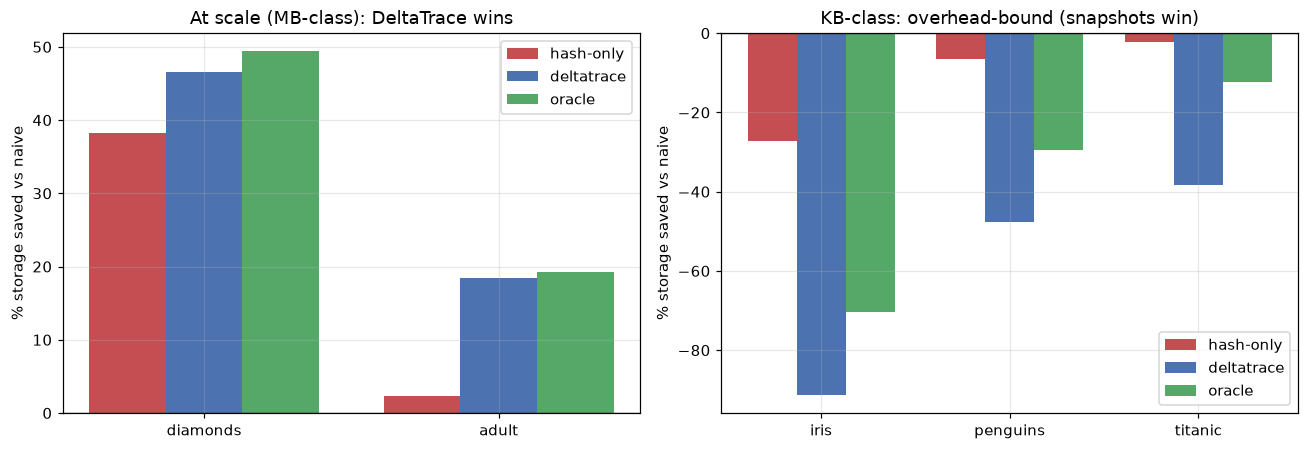

In [7]:
large = ["diamonds", "adult"]; small = ["iris", "penguins", "titanic"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
def saved(d, s):
    return storage[(storage.dataset == d) & (storage.system == s)]["saved_pct"].iloc[0]
for ax, group, title in [(axes[0], large, "At scale (MB-class): DeltaTrace wins"),
                         (axes[1], small, "KB-class: overhead-bound (snapshots win)")]:
    x = np.arange(len(group)); w = 0.26
    for i, (sysn, col) in enumerate([("hash-only", "#C44E52"), ("deltatrace", "#4C72B0"), ("oracle", "#55A868")]):
        ax.bar(x + (i - 1) * w, [saved(d, sysn) for d in group], w, label=sysn, color=col)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(group)
    ax.set_ylabel("% storage saved vs naive"); ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

## 3. The gap widens with history length

Naive storage grows linearly with the number of versions; a delta store pays for the base once and adds only small deltas. The longer the history, the bigger the win -- and DeltaTrace stays close to the oracle throughout, while hash-only trails.

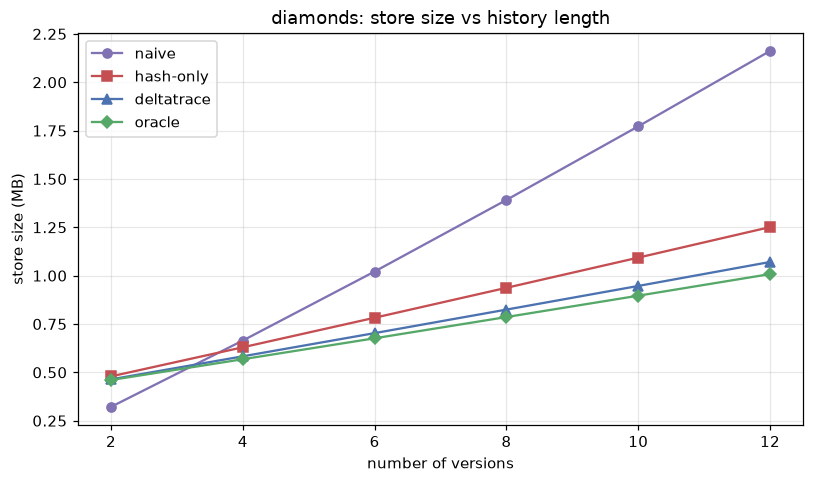

In [8]:
from benchmarks.run import run_dataset
ks = [2, 4, 6, 8, 10, 12]
series = {s: [] for s in ["naive", "hash-only", "deltatrace", "oracle"]}
for k in ks:
    r = run_dataset("diamonds", n_versions=k, seed=0)
    for s in series:
        series[s].append(r.storage[r.storage.system == s]["kb"].iloc[0] / 1024)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
for s, col, mk in [("naive", "#8172B3", "o"), ("hash-only", "#C44E52", "s"),
                   ("deltatrace", "#4C72B0", "^"), ("oracle", "#55A868", "D")]:
    ax.plot(ks, series[s], marker=mk, label=s, color=col)
ax.set_xlabel("number of versions"); ax.set_ylabel("store size (MB)")
ax.set_title("diamonds: store size vs history length"); ax.legend()
plt.tight_layout(); plt.show()

## 4. Correctness is never traded away

Across every dataset and every system, all 10 versions reconstruct **exactly** -- byte-for-byte multiset equality with the original. The systems differ only in storage and provenance quality. That is error confinement at benchmark scale.

In [9]:
recon = storage.pivot(index="dataset", columns="system", values="reconstruct_ok")
print("Exact reconstruction of all versions:")
recon

Exact reconstruction of all versions:


system,deltatrace,hash-only,naive,oracle
dataset,,,,
adult,True,True,True,True
diamonds,True,True,True,True
iris,True,True,True,True
penguins,True,True,True,True
titanic,True,True,True,True


## Takeaways

* **Identity recovery is a universal win.** Hash-only cannot see edits at all (recall ~0.94, thousands of edited rows mis-classified); DeltaTrace recovers ~0.99 across every dataset.
* **Storage is a scale win.** On MB-class keyless tables DeltaTrace saves real space and nearly matches an oracle with a perfect key, while hash-only barely helps. On tiny tables, snapshots are fine -- and DeltaTrace says so honestly.
* **Correctness is non-negotiable.** Every configuration reconstructs exactly. The matcher only ever trades storage, never your data.